<a href="https://colab.research.google.com/github/gon311/semester-2026-1/blob/python/%ED%8C%8C%EB%8D%B0%EC%B2%98_%EC%A4%91%EA%B0%84_%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!apt-get install -y fonts-nanum
!fc-cache -fv
!rm ~/.cache/matplotlib -rf

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  fonts-nanum
0 upgraded, 1 newly installed, 0 to remove and 6 not upgraded.
Need to get 10.3 MB of archives.
After this operation, 34.1 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fonts-nanum all 20200506-1 [10.3 MB]
Fetched 10.3 MB in 1s (19.2 MB/s)
Selecting previously unselected package fonts-nanum.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/s

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time
import re

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64)",
    "Accept-Language": "ko-KR,ko;q=0.9",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9",
    "Connection": "keep-alive"
}

def clean_title(text):
    text = re.sub(r"[^\w\s가-힣]", "", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def clean_summary(text):
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def crawl_daum_news(keyword, target_count):
    data = []
    page = 1

    while len(data) < target_count:
        url = f"https://search.daum.net/search?w=news&q={keyword}&p={page}"
        res = requests.get(url, headers=headers, timeout=3)
        soup = BeautifulSoup(res.text, "html.parser")

        items = soup.select("ul.c-list-basic > li")

        print("페이지:", page, "아이템 수:", len(items))  # 디버깅용

        for item in items:
            title_tag = item.select_one("strong.tit-g a")
            press_tag = item.select_one(".item-writer .txt_info")

            if not title_tag:
                continue

            title = clean_title(title_tag.get_text()) ## title_tag 안에 포함된 모든 텍스트 추출 후 전처리
            link = title_tag.get("href")
            press = press_tag.get_text(strip=True) if press_tag else None

            # print("현재수집:", len(data), link) # 디버깅용

            # 상세페이지 - 요약문 수집
            if "v.daum.net" in link:
                try:
                    res_detail = requests.get(link, headers=headers, timeout=3)
                    soup_detail = BeautifulSoup(res_detail.text, "html.parser")

                    summary_tag = soup_detail.select_one("strong.summary_view")
                    summary = clean_summary(summary_tag.get_text(" ", strip=True)) if summary_tag else None
                except Exception as e:
                    print("상세페이지 에러:", e)   # 디버깅용
                    summary = None
            else:
                summary = None

            # 데이터 합치기
            data.append({
                "title": title,
                "press": press,
                "summary": summary,
                "link": link,
                "keyword": keyword
            })

            # 목표 개수 도달 시 종료
            if len(data) >= target_count:
                break

            # 서버 부하 방지
            time.sleep(0.2)

        page += 1
        time.sleep(0.5)

    return pd.DataFrame(data)


# 실행
df1 = crawl_daum_news("가뭄", 100)
df2 = crawl_daum_news("홍수", 100)

# 확인
print(df1.head())

페이지: 1 아이템 수: 10
페이지: 2 아이템 수: 10
페이지: 3 아이템 수: 10
페이지: 4 아이템 수: 10
페이지: 5 아이템 수: 10
페이지: 6 아이템 수: 10
페이지: 7 아이템 수: 10
페이지: 8 아이템 수: 10
페이지: 9 아이템 수: 10
페이지: 10 아이템 수: 10
페이지: 1 아이템 수: 10
페이지: 2 아이템 수: 10
페이지: 3 아이템 수: 10
페이지: 4 아이템 수: 10
페이지: 5 아이템 수: 10
페이지: 6 아이템 수: 10
페이지: 7 아이템 수: 10
페이지: 8 아이템 수: 10
페이지: 9 아이템 수: 10
페이지: 10 아이템 수: 10
                                title    press  \
0               가뭄 일상화광주전남 선제적 대응책 시급     남도일보   
1  경지넷이 꼽은 경기도 어젠다 침수가뭄 반복수자원관리국 신설해야     인천일보   
2      이상기후에 돌발 가뭄 증가AI 활용해 농업가뭄 대비한다  kbc광주방송   
3    가뭄 주의 격상 통영 욕지도 62억 투입 지하수저류댐 추진     연합뉴스   
4                욕지도 가뭄 심화 가뭄단계 주의 격상      KNN   

                                             summary  \
0  완도 넙도, 해수담수화 시설로 가뭄 ‘관심’ 단계 해제 ‘주목’ 올봄 고온·강수량 ...   
1  ③ 경기도 물 관리 위기 심화 반도체 클러스터, 대량 용수 필요 '물 순환' 부실…...   
2                                               None   
3                                               None   
4                                               None   

                    

In [ ]:
# 결측치 비율 확인
print(df1['summary'].isnull().value_counts(normalize=True))

# 도메인별 결측치 확인 (원인 파악)
df1['is_daum'] = df1['link'].str.contains('v.daum.net')
missing_by_domain = df1.groupby('is_daum')['summary'].apply(lambda x: x.isnull().mean())
print(missing_by_domain)

# 제목과 언론사가 같은 중복 행 제거
df1 = df1.drop_duplicates(subset=['title', 'press'])

# 결측치 비율 재확인
missing_by_domain = df1.groupby('is_daum')['summary'].apply(lambda x: x.isnull().mean())
print(missing_by_domain)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    100 non-null    object
 1   press    100 non-null    object
 2   summary  52 non-null     object
 3   link     100 non-null    object
 4   keyword  100 non-null    object
 5   is_daum  100 non-null    bool  
dtypes: bool(1), object(5)
memory usage: 4.1+ KB
None
summary
False    0.52
True     0.48
Name: proportion, dtype: float64
is_daum
True    0.48
Name: summary, dtype: float64
is_daum
True    0.48
Name: summary, dtype: float64


In [ ]:
# 결측치 비율 확인
print(df2['summary'].isnull().value_counts(normalize=True))

# 도메인별 결측치 확인 (원인 파악)
df2['is_daum'] = df2['link'].str.contains('v.daum.net')
missing_by_domain = df2.groupby('is_daum')['summary'].apply(lambda x: x.isnull().mean())
print(missing_by_domain)

# 제목과 언론사가 같은 중복 행 제거
df2 = df2.drop_duplicates(subset=['title', 'press'])

# 결측치 비율 재확인
missing_by_domain = df2.groupby('is_daum')['summary'].apply(lambda x: x.isnull().mean())
print(missing_by_domain)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    100 non-null    object
 1   press    100 non-null    object
 2   summary  33 non-null     object
 3   link     100 non-null    object
 4   keyword  100 non-null    object
dtypes: object(5)
memory usage: 4.0+ KB
None
summary
True     0.67
False    0.33
Name: proportion, dtype: float64
is_daum
True    0.67
Name: summary, dtype: float64
<bound method IndexOpsMixin.value_counts of 0     True
1     True
2     True
3     True
4     True
      ... 
95    True
96    True
97    True
98    True
99    True
Name: is_daum, Length: 100, dtype: bool>
is_daum
True    0.67
Name: summary, dtype: float64


###  결측치에 대한 고민

중복 값 없이, 다음 뉴스 도메인 안에서 48%(가뭄), 67%(홍수)의 요약본 결측율 발생

▶ 기사를 송고한 언론사와 무관한가?

In [ ]:
import pandas as pd

df1 = pd.read_csv("/content/df1.csv")

# 1. 언론사별 전체 기사 수와 결측치 수 계산
# size()를 사용하여 전체 행(row)의 개수를 정확히 파악
press_analysis = df1.groupby('press')['summary'].agg([
    ('총수집건수', 'size'),
    ('요약문보유', 'count'),
    ('결측치수', lambda x: x.isnull().sum()),
    ('결측비율', lambda x: x.isnull().mean())
]).reset_index()

# 총 수집 건수가 많은 순으로 정렬
print(press_analysis.sort_values(by='총수집건수', ascending=False).head(20))



     press  총수집건수  요약문보유  결측치수      결측비율
36    연합뉴스      7      2     5  0.714286
18     뉴스1      7      4     3  0.428571
16    노컷뉴스      6      4     2  0.333333
21     뉴시스      6      5     1  0.166667
8   강원도민일보      5      1     4  0.800000
31    서울신문      5      4     1  0.200000
43  파이낸셜뉴스      4      1     3  0.750000
6      YTN      3      0     3  1.000000
17    농민신문      3      1     2  0.666667
28   메트로경제      3      2     1  0.333333
9     강원일보      3      3     0  0.000000
14    경향신문      3      1     2  0.666667
15    남도일보      3      3     0  0.000000
34   아시아경제      3      3     0  0.000000
33   스포츠동아      2      0     2  1.000000
4      KNN      2      0     2  1.000000
24    데일리안      2      2     0  0.000000
41    전남일보      2      2     0  0.000000
44     한겨레      2      0     2  1.000000
13    경북일보      1      1     0  0.000000


In [ ]:
# 1. 언론사별 전체 기사 수와 결측치 수 계산
# size()를 사용하여 전체 행(row)의 개수를 정확히 파악
press_analysis2 = df2.groupby('press')['summary'].agg([
    ('총수집건수', 'size'),
    ('요약문보유', 'count'),
    ('결측치수', lambda x: x.isnull().sum()),
    ('결측비율', lambda x: x.isnull().mean())
]).reset_index()

# 총 수집 건수가 많은 순으로 정렬
print(press_analysis2.sort_values(by='총수집건수', ascending=False).head(20))



      press  총수집건수  요약문보유  결측치수      결측비율
20      뉴시스     25      4    21  0.840000
16      뉴스1      5      1     4  0.800000
1       KBS      5      0     5  1.000000
18  뉴스트리코리아      4      0     4  1.000000
4       OBS      4      0     4  1.000000
24     매일경제      3      2     1  0.333333
10     경북매일      2      2     0  0.000000
11     경향신문      2      0     2  1.000000
2       MBN      2      0     2  1.000000
38   연합뉴스TV      2      0     2  1.000000
41     전자신문      2      1     1  0.500000
29    브릿지경제      2      2     0  0.000000
19     뉴스펭귄      2      2     0  0.000000
17      뉴스엔      2      0     2  1.000000
14     노컷뉴스      2      2     0  0.000000
15     농민신문      2      2     0  0.000000
48    헤럴드경제      2      1     1  0.500000
13     남도일보      1      1     0  0.000000
12     광주일보      1      1     0  0.000000
9    강원도민일보      1      0     1  1.000000


In [ ]:
# 1. 데이터 합치기
df = pd.concat([df1, df2], ignore_index=True)

# 2. 키워드별 + 언론사별 결측치 계산
df['is_missing'] = df['summary'].isnull().astype(int)

# 그룹화하여 평균(비율) 계산
report = df.groupby(['keyword', 'press'])['is_missing'].agg(['mean', 'size']).reset_index()
report.columns = ['keyword', 'press', 'missing_ratio', 'total_count']

# 시각화 가독성을 위해 데이터가 너무 적은 언론사는 제외
report = report[report['total_count'] >= 2]

# 비율 높은 순 정렬
report = report.sort_values(by='missing_ratio', ascending=False)



/tmp/ipykernel_1604/4073896937.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


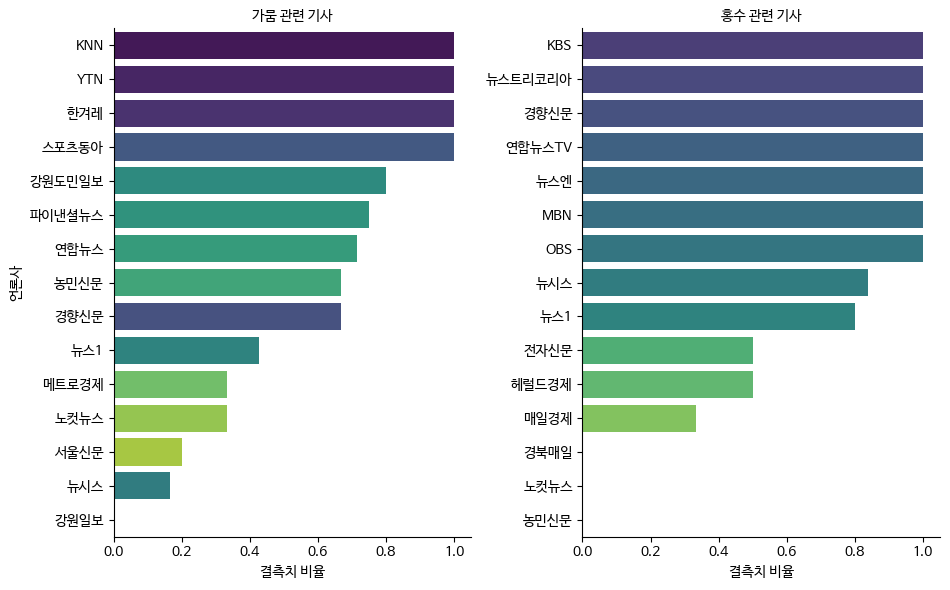

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rc('font', family='NanumBarunGothic')

# 시각화 실행
g = sns.catplot(
    data=report.groupby('keyword').head(15), # 각 키워드별 상위 15개씩만
    kind="bar",
    x="missing_ratio", y="press", col="keyword",
    palette="viridis", height=6, aspect=0.8,
    sharey=False # 키워드마다 언론사 목록이 다를 수 있으므로 False
)

g.set_axis_labels("결측치 비율", "언론사")
g.set_titles("{col_name} 관련 기사")
plt.tight_layout()
plt.show()

In [ ]:
# 1. 원본 보존을 위해 새로운 컬럼 생성 (결측치는 제목으로 보충)
df['final_summary'] = df['summary'].fillna(df['title'])

# 2. 대체된 데이터인지 표시 (사후 분석용)
df['is_imputed'] = df['summary'].isnull()

# 3. 결과 확인
print(f"대체 완료 건수: {df['is_imputed'].sum()}건")

df.to_csv('news_data.csv', index=False, encoding='utf-8-sig')

대체 완료 건수: 115건


1. 언론사 보도 비중 비교 (Top 10 언론사)

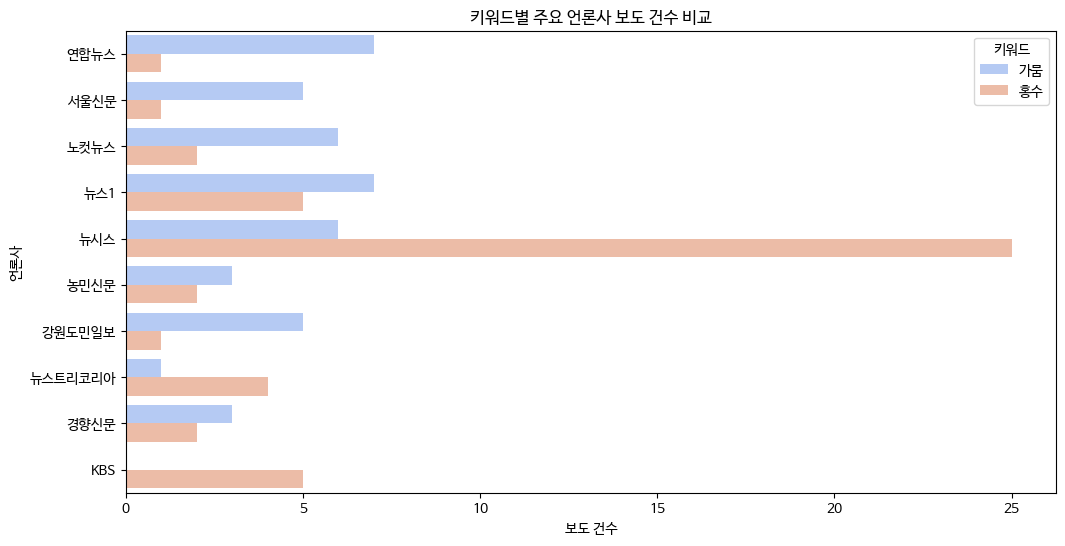

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("/content/news_data.csv")

# 1. 상위 10개 언론사 추출 (전체 데이터 기준)
top_press = df['press'].value_counts().nlargest(10).index #
df_top = df[df['press'].isin(top_press)]

# 2. 시각화
plt.rc('font', family='NanumBarunGothic')

plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, y='press', hue='keyword', palette='coolwarm')
plt.title('키워드별 주요 언론사 보도 건수 비교')
plt.xlabel('보도 건수')
plt.ylabel('언론사')
plt.legend(title='키워드')
plt.show()

2. 키워드별 주요 단어 분석

In [ ]:
from collections import Counter

def get_top_nouns(text_list, top_n=10):
    # 간단한 단어 분리 (2글자 이상만)
    words = " ".join(text_list).split()
    words = [w for w in words if len(w) > 1]
    return Counter(words).most_common(top_n)

# 키워드별 단어 추출
drought_top = get_top_nouns(df[df['keyword']=='가뭄']['title'])
flood_top = get_top_nouns(df[df['keyword']=='홍수']['title'])

# 표 형태로 만들기
comparison_df = pd.DataFrame({
    '가뭄 키워드': [word for word, count in drought_top],
    '가뭄 빈도': [count for word, count in drought_top],
    '홍수 키워드': [word for word, count in flood_top],
    '홍수 빈도': [count for word, count in flood_top]
})

print("### 키워드별 제목 내 주요 단어 TOP 10 ###")
print(comparison_df)

### 키워드별 제목 내 주요 단어 TOP 10 ###
  가뭄 키워드  가뭄 빈도 홍수 키워드  홍수 빈도
0     가뭄     58     홍수     44
1     대응      9     피해     18
2     주의      8    하와이     13
3     겨울      8    홍수로     11
4    욕지도      6    브라질      7
5     강릉      6    홍수에      6
6     대비      6     최악      5
7     선제      6     AI      5
8   농업용수      6     구글      5
9    강수량      6     돌발      5
